<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/Analyse_BART_DRS_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
import matplotlib
import numpy
import os
import pandas
import scipy
import sklearn
import statsmodels.api
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 658, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 658 (delta 50), reused 2 (delta 2), pack-reused 584 (from 1)
Receiving objects: 100% (658/658), 1.76 MiB | 18.78 MiB/s, done.
Resolving deltas: 100% (415/415), done.


In [9]:
from innoprod.digital_readiness_score import DRS_LEVELS
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.plotting_tools import rand_jitter

# Read in data

In [5]:
bart_drs_predictions_df = get_sheet_dfs(
    sheet_id="1hi2l8WiY98VUrR6XfxI8w9cOgfxgfuqSvA7S95-fH3M",
    ranges={"Results": "Sheet1!A1:E221"}
  )['Results']
# bart_drs_predictions_df

In [6]:
col_types = {
    'Client ID': 'str',
    'Current Digital Readiness Score (refer to PAS:1040)': pandas.Int64Dtype(),
    'Predicted DRS': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  bart_drs_predictions_df[col] = bart_drs_predictions_df[col].astype(ty)

# Analysis

In [7]:
bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'].value_counts().sort_index()

,count
Current Digital Readiness Score (refer to PAS:1040),
1,5
2,14
3,28
4,43
5,56
6,36
7,10
8,7
9,1


In [8]:
bart_drs_predictions_df['Predicted DRS'].value_counts().sort_index()

,count
Predicted DRS,
1,6
2,4
3,8
4,50
5,101
6,4
7,27
8,20


Text(0.5, 0, 'Digital Readiness Score')

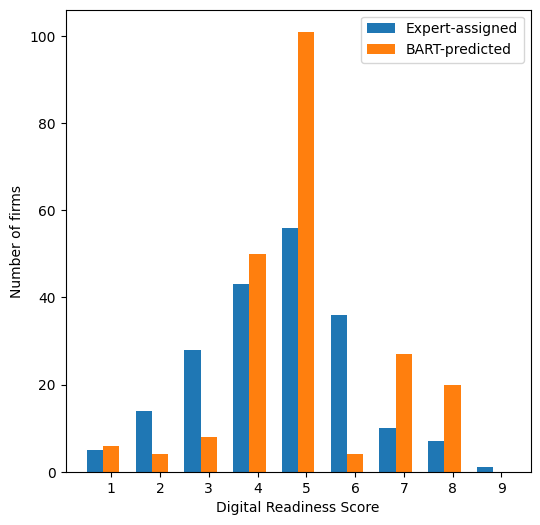

In [14]:
x = numpy.arange(1, len(DRS_LEVELS)+1)
width = 1/3

fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

multiplier = -1

for col, label in {'Current Digital Readiness Score (refer to PAS:1040)': 'Expert-assigned', 'Predicted DRS': 'BART-predicted'}.items():
  y = bart_drs_predictions_df[col].value_counts()
  y = y.reindex(range(1, len(DRS_LEVELS)+1), fill_value=0)
  offset = width * multiplier
  rects = ax.bar(
      x + offset,
      y,
      width,
      label=label
  )
  multiplier += 1

ax.set_xticks(x)

ax.legend()

ax.set_ylabel('Number of firms')
ax.set_xlabel('Digital Readiness Score')

## Direct comparison

In [ ]:
bart_drs_predictions_df[['Current Digital Readiness Score (refer to PAS:1040)', 'Predicted DRS']].corr()

,Current Digital Readiness Score (refer to PAS:1040),Predicted DRS
Current Digital Readiness Score (refer to PAS:1040),1.000000,0.229828
Predicted DRS,0.229828,1.000000


In [ ]:
comparison_df = bart_drs_predictions_df.groupby(['Current Digital Readiness Score (refer to PAS:1040)', 'Predicted DRS']).size().reset_index(name='count')
heat = numpy.zeros((9,9))
heat[
      comparison_df['Current Digital Readiness Score (refer to PAS:1040)'].to_numpy()-1,
      comparison_df['Predicted DRS'].to_numpy()-1
    ] = comparison_df['count'].to_numpy().T
heat = heat.T
heat

array([[ 0.,  0.,  1.,  3.,  1.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  3.,  1.,  0.,  0.,  0.],
       [ 1.,  1.,  2.,  1.,  2.,  0.,  0.,  0.,  1.],
       [ 1.,  4., 12.,  9., 15.,  5.,  1.,  2.,  0.],
       [ 2.,  7., 13., 22., 21., 19.,  1.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  3.,  0.,  0.,  0.],
       [ 1.,  1.,  0.,  3.,  8.,  4.,  4.,  3.,  0.],
       [ 0.,  1.,  0.,  5.,  5.,  3.,  4.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [ ]:
lr_model = sklearn.linear_model.LinearRegression()
# Check reshaping
X = bart_drs_predictions_df.dropna()['Current Digital Readiness Score (refer to PAS:1040)'].to_numpy().reshape(-1, 1)
Y = bart_drs_predictions_df.dropna()['Predicted DRS'].to_numpy()
lr_model.fit(X, Y)

LinearRegression()

In [ ]:
lr_model.score(X, Y)

0.05282093481654426

Text(0, 0.5, 'Number of firms')

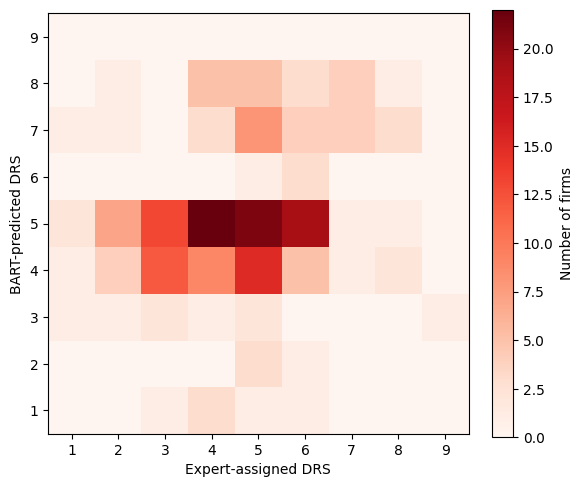

In [ ]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

im = ax.imshow(heat, cmap="Reds")

ax.xaxis.set_inverted(False)
ax.yaxis.set_inverted(False)

ax.set_xlabel('Expert-assigned DRS')
ax.set_ylabel('BART-predicted DRS')

ax.set_xticks(range(0,9), labels=[str(i) for i in range(1,10)])
ax.set_yticks(range(0,9), labels=[str(i) for i in range(1,10)])

cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046)
cbar.ax.set_ylabel("Number\nof firms", rotation=0, y=1.01, labelpad=3)

In [ ]:
bart_drs_predictions_df['Prediction diff'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] - bart_drs_predictions_df['Predicted DRS']
pred_diff_counts = bart_drs_predictions_df.groupby('Prediction diff').size().reset_index(name='count')
pred_diff_counts

,Prediction diff,count
0,-6,2
1,-5,1
2,-4,7
3,-3,16
4,-2,29
5,-1,44
6,0,40
7,1,38
8,2,9
9,3,8


In [ ]:
bart_drs_predictions_df['Pred 5 diff'] = bart_drs_predictions_df['Current Digital Readiness Score (refer to PAS:1040)'] - 5
pred_5_diff_counts = bart_drs_predictions_df.groupby('Pred 5 diff').size().reset_index(name='count')
pred_5_diff_counts

,Pred 5 diff,count
0,-4,5
1,-3,14
2,-2,28
3,-1,43
4,0,56
5,1,36
6,2,10
7,3,7
8,4,1


Text(0, 0.5, 'Count')

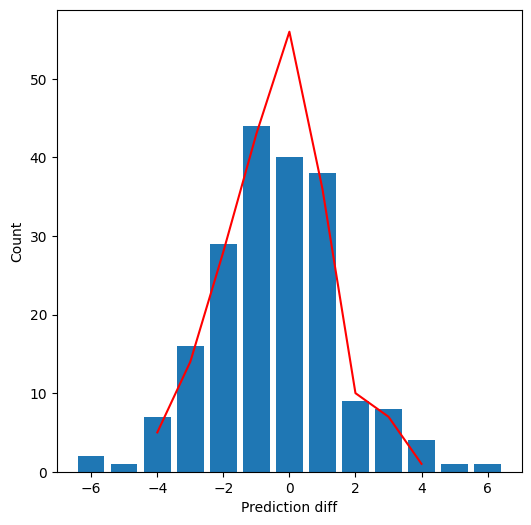

In [ ]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))

ax.bar(pred_diff_counts['Prediction diff'], pred_diff_counts['count'])
ax.plot(pred_5_diff_counts['Pred 5 diff'], pred_5_diff_counts['count'], c='r')


ax.set_xlabel('Prediction diff')
ax.set_ylabel('Count')


In [ ]:
bart_drs_predictions_df['Prediction diff'].mean()

np.float64(-0.44)

In [ ]:
bart_drs_predictions_df['Prediction diff'].std()

np.float64(1.9352327064569532)

<Axes: ylabel='Density'>

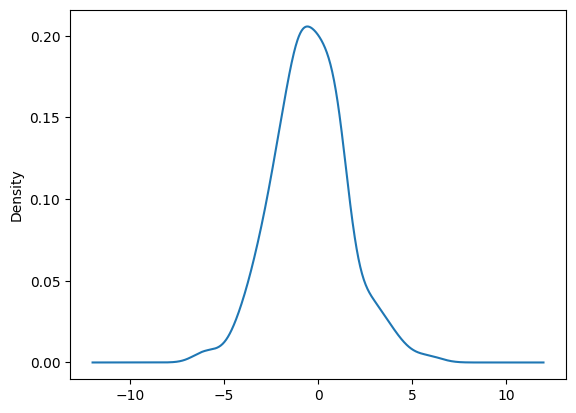

In [ ]:
bart_drs_predictions_df['Prediction diff'].plot.density()

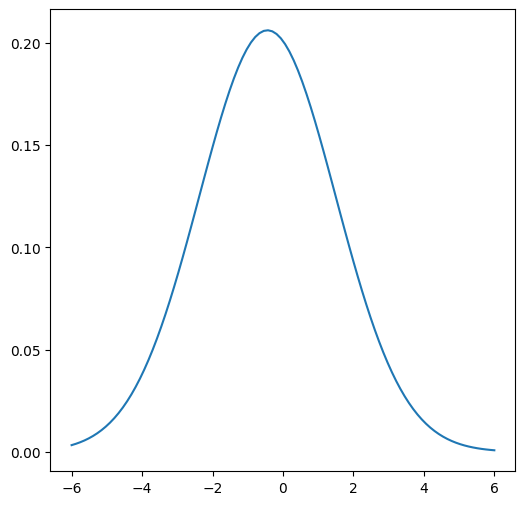

In [ ]:
x = numpy.linspace(bart_drs_predictions_df['Prediction diff'].min(), bart_drs_predictions_df['Prediction diff'].max(), 100)
pred_diff_norm_pdf = scipy.stats.norm.pdf(
    x,
    loc=bart_drs_predictions_df['Prediction diff'].mean(),
    scale=bart_drs_predictions_df['Prediction diff'].std()
  )
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.plot(x, pred_diff_norm_pdf)